# Import Data 

In [1]:
import pandas as pd
import seaborn as sns

import numpy as np 
import matplotlib.pyplot as plt 

home = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Home_Team.csv")
away = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Away_Team.csv")
events = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawEventsData.csv")

/var/folders/lw/fl7prrw1671044k3vst005600000gq/T/ipykernel_9045/3004938885.py:7: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  home = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Home_Team.csv")
/var/folders/lw/fl7prrw1671044k3vst005600000gq/T/ipykernel_9045/3004938885.py:8: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  away = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Away_Team.csv")


# Basic Information of Data Events

In [2]:
print("Number of data",events.shape)

events.describe()

Number of data (1935, 14)


,Period,Start Frame,Start Time [s],End Frame,End Time [s],Start X,Start Y,End X,End Y
count,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1849.000000,1849.000000,1221.000000,1221.000000
mean,1.468217,65422.160207,2616.886408,65444.214470,2617.768579,0.494446,0.518096,0.499476,0.512776
std,0.499118,39412.118805,1576.484752,39410.201977,1576.408079,0.238115,0.297417,0.229955,0.306112
min,1.000000,51.000000,2.040000,51.000000,2.040000,-0.010000,-0.030000,-0.080000,-0.040000
25%,1.000000,30974.500000,1238.980000,30978.000000,1239.120000,0.320000,0.250000,0.340000,0.240000
50%,1.000000,64182.000000,2567.280000,64239.000000,2569.560000,0.500000,0.520000,0.510000,0.520000
75%,2.000000,96722.000000,3868.880000,96756.000000,3870.240000,0.680000,0.790000,0.660000,0.780000
max,2.000000,140265.000000,5610.600000,140298.000000,5611.920000,1.030000,1.020000,1.020000,1.040000


**we have 1935 rows of 14 columns**

we can see that columns such as **Start X,Start Y,End X, End Y** have < 1935 values so we will check if those NaN values are normal


# Missing Value Analysis

In [3]:
print(f"Events Columns: {events.columns}")

Events Columns: Index(['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]',
       'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y',
       'End X', 'End Y'],
      dtype='object')


In [4]:
for col in events.columns:
    print(f"{col} contains: {events[col].isnull().sum()} null values")

Team contains: 0 null values
Type contains: 0 null values
Subtype contains: 1067 null values
Period contains: 0 null values
Start Frame contains: 0 null values
Start Time [s] contains: 0 null values
End Frame contains: 0 null values
End Time [s] contains: 0 null values
From contains: 0 null values
To contains: 971 null values
Start X contains: 86 null values
Start Y contains: 86 null values
End X contains: 714 null values
End Y contains: 714 null values


we are going to do extra analysis on **subtype,to,cordinates** to check if the missing values are due to mistake or because of event actions on football

### Subtype

In [8]:
# check which event types produce those null values
events[events['Subtype'].isnull()]['Type'].value_counts()

Type
PASS              916
RECOVERY           63
BALL OUT           38
BALL LOST          30
FAULT RECEIVED     20
Name: count, dtype: int64

we are going to check on those categories if they have also subtypes but in order to check also the null values we are going to fill them with NONE 

In [12]:
events['Subtype'] = events['Subtype'].fillna("NONE")

In [13]:
passes = events[events['Type']=="PASS"]
recovery = events[events['Type']=='RECOVERY']
ball_out = events[events['Type']=="BALL OUT"]
ball_lost = events[events['Type']=="BALL LOST"]
fault_received = events[events['Type']=="FAULT RECEIVED"]


In [19]:
print("Passes Subtypes")
print(passes['Subtype'].value_counts())
print("######################")
print("Recovery Subtypes")
print(recovery["Subtype"].value_counts())
print("######################")
print("Ball Out Subtype")
print(ball_out['Subtype'].value_counts())

Passes Subtypes
Subtype
NONE                           916
HEAD                            27
GOAL KICK                       12
CROSS                            7
DEEP BALL                        1
HEAD-INTERCEPTION-CLEARANCE      1
Name: count, dtype: int64
######################
Recovery Subtypes
Subtype
INTERCEPTION    145
NONE             63
THEFT            31
SAVED             6
BLOCKED           3
Name: count, dtype: int64
######################
Ball Out Subtype
Subtype
NONE              38
CLEARANCE          5
HEAD               4
HEAD-CLEARANCE     1
CROSS              1
Name: count, dtype: int64


In [21]:
print("Ball Lost Subtype")
print(ball_lost['Subtype'].value_counts())
print("######################")
print("Fault Received Subtype")
print(fault_received['Subtype'].value_counts())

Ball Lost Subtype
Subtype
INTERCEPTION              114
THEFT                      38
NONE                       30
HEAD-INTERCEPTION          15
HEAD                       10
CROSS-INTERCEPTION          8
FORCED                      6
GOAL KICK-INTERCEPTION      4
HAND BALL                   3
CLEARANCE                   2
OFFSIDE                     1
FORCED-END HALF             1
CLEARANCE-INTERCEPTION      1
Name: count, dtype: int64
######################
Fault Received Subtype
Subtype
NONE    20
Name: count, dtype: int64


## Observations

- Most **Pass events** do not contain a subtype (`NONE`), which indicates a normal pass.
- Some passes include additional context such as **HEAD**, **CROSS**, or **GOAL KICK**.
- **Recovery events** are mainly caused by **interceptions**, followed by standard recoveries (`NONE`) and **theft** (tackles).
- **Ball Lost events** mostly occur due to **interceptions** and **theft**, meaning the opposing team regained possession.
- **Ball Out events** are mostly simple ball exits (`NONE`), but sometimes occur after **clearances** or **headers**.
- **Fault Received** events do not include subtype information in this dataset.

Overall, the subtype distribution appears **consistent and logically aligned with football event tagging**, suggesting there are **no major data quality issues** in the `Subtype` column.

### To Column

In [22]:
# we are going to take "problematic rows"
null_to = events[events['To'].isnull()]

In [24]:
null_to.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
6,Away,BALL LOST,INTERCEPTION,1,451,18.04,504,20.16,Player15,NaN,0.26,0.92,0.64,0.93
7,Away,CHALLENGE,GROUND-LOST,1,504,20.16,504,20.16,Player23,NaN,0.61,0.93,NaN,NaN
8,Home,CHALLENGE,GROUND-WON,1,504,20.16,504,20.16,Player3,NaN,0.62,0.92,NaN,NaN
9,Home,RECOVERY,INTERCEPTION,1,504,20.16,504,20.16,Player3,NaN,0.62,0.92,NaN,NaN


**we will check the event types**

In [25]:
null_to["Type"].value_counts()

Type
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: count, dtype: int64

### Events where To should be normally Null

- Recovery -> player regains position
- Ball Lost -> player losses possession
- Ball Out -> ball leaves field
- Shot -> player shoots
- Set Piece -> restart action
- Fault Received -> player who suffere the foul
- Card -> referee give a card to a player (we say player received a card)

for the challenge event due to the dataset being a certain way including both home and away we will check if both teams appear for the same moment , to confirm it

In [28]:
events[events['Type']=='CHALLENGE'][['Team','From',"Subtype"]]

,Team,From,Subtype
7,Away,Player23,GROUND-LOST
8,Home,Player3,GROUND-WON
18,Home,Player6,AERIAL-WON
21,Away,Player23,AERIAL-LOST
30,Away,Player18,AERIAL-LOST
...,...,...,...
1919,Home,Player1,GROUND-FAULT-WON
1923,Away,Player17,AERIAL-FAULT-LOST
1924,Home,Player7,AERIAL-FAULT-WON
1931,Home,Player1,AERIAL-LOST


that confirms it so we don't have a problem regarding with To column for the **CHALLENGE** Type being null

# Coordinates Columns
first verify symmetry

In [29]:
(events['Start X'].isnull() != events['Start Y'].isnull()).sum()

0

the same for the end coordinates

In [30]:
(events['End X'].isnull() != events['End Y'].isnull()).sum()

0

**check which events causing Start Coordinates**

In [31]:
start_null = events[events['Start X'].isnull()]
start_null["Type"].value_counts()

Type
SET PIECE    80
CARD          6
Name: count, dtype: int64

completely normal 
- Card -> referee decision
- Set Piece -> doesn't so clear spatial origin

In [32]:
# same for end coordinates
end_null = events[events['End X'].isnull()]
end_null['Type'].value_counts()

Type
CHALLENGE         311
RECOVERY          248
SET PIECE          80
BALL LOST          48
FAULT RECEIVED     20
CARD                6
BALL OUT            1
Name: count, dtype: int64

#### Events Causing Missing `End X` / `End Y` Coordinates

| Event Type | Count | Why End Coordinates Are Missing |
|---|---|---|
| CHALLENGE | 311 | Duel between players; the ball may not move spatially. |
| RECOVERY | 248 | A player regains possession at a specific location; no ball trajectory is recorded. |
| SET PIECE | 80 | Marks a restart event (e.g., corner, free kick) rather than a ball movement. |
| BALL LOST | 48 | Possession ends, but the ball trajectory after the loss is not tracked. |
| FAULT RECEIVED | 20 | Foul event involving a player; it does not describe ball movement. |
| CARD | 6 | Administrative referee decision event; no spatial ball movement involved. |
| BALL OUT | 1 | The ball leaves the field; the event records the location where it occurred. |

**so the end coordinates are okay**

## Event Distribution

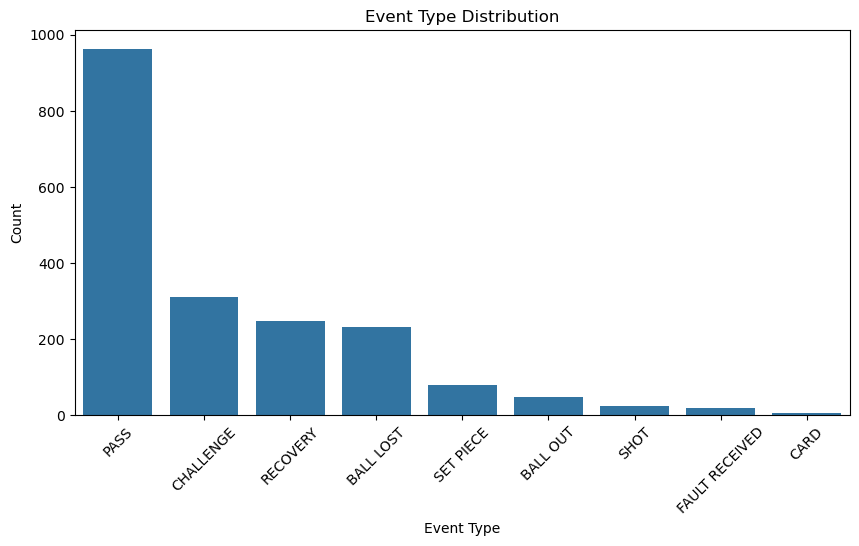

In [34]:
event_distribution = events['Type'].value_counts()
plt.figure(figsize=(10,5))

sns.barplot(
    x=event_distribution.index,
    y = event_distribution.values
)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

from the plot we can see that the game had a lot of:
- possesion
- duels (challenges) aggresive game
- frequency on losing and recovering the ball

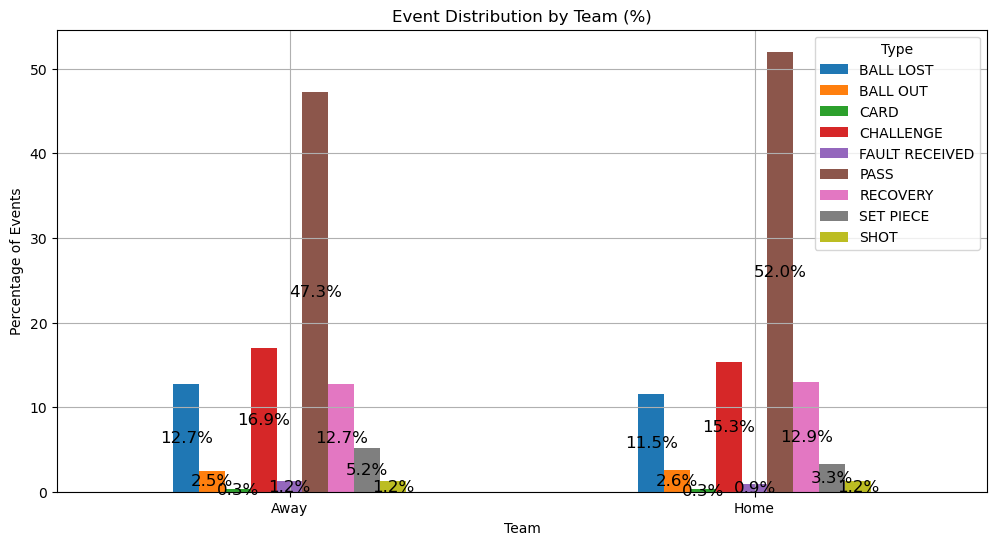

In [44]:

# count events
team_events = events.groupby(['Team','Type']).size().unstack(fill_value=0)

# convert counts → percentages per team
team_events_pct = team_events.div(team_events.sum(axis=1), axis=0) * 100

ax = team_events_pct.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Event Distribution by Team (%)")
plt.xlabel("Team")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=0)
plt.grid(True)

# add percentage labels
for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=12)

plt.show()

### Event Distribution by Team

The percentage distribution of event types is relatively balanced between the Home and Away teams. Most event categories appear with similar proportions for both teams, suggesting that the match dynamics and types of actions performed were broadly comparable.

Nevertheless, some event types show moderate differences in frequency between the teams. These variations may reflect tactical differences, such as higher defensive pressure, more recoveries, or increased attacking actions by one team.

# Per Period

<Figure size 1000x500 with 0 Axes>

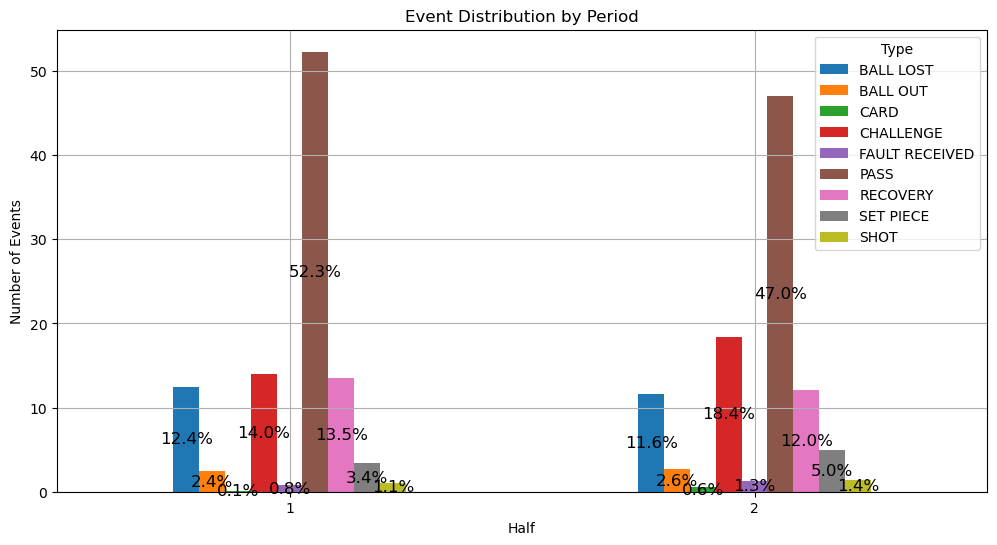

In [47]:
plt.figure(figsize=(10,5))

period_events = events.groupby(["Period","Type"]).size().unstack(fill_value=0)

period_events_pct = period_events.div(period_events.sum(axis=1),axis=0)*100


ax = period_events_pct.plot(
    kind='bar',
    stacked=False,
    figsize=(12,6) 
)

plt.title("Event Distribution by Period")
plt.xlabel("Half")
plt.ylabel("Number of Events")
plt.grid(True)
plt.xticks(rotation=0)

for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=12)
plt.show()


# SubTypes Distribution 

In [51]:
def plot_subtype_distribution(df,type_col="Type",subtype_col='Subtype',show_pct=True):
    event_types = df[type_col].unique()

    for event in event_types:
        subset = df[df[type_col]==event]
        counts = subset[subtype_col].value_counts()

        if show_pct:
            counts = counts/counts.sum()*100
        plt.figure(figsize=(8,4))
        sns.barplot(
            x=counts.index,
            y=counts.values
        )

        plt.title(f"{event} Subtype Distribution")
        plt.xlabel("Subtype")
        plt.ylabel("Percentage % " if show_pct else "Count")
        plt.xticks(rotation=90)
        plt.grid(True)

        plt.show()

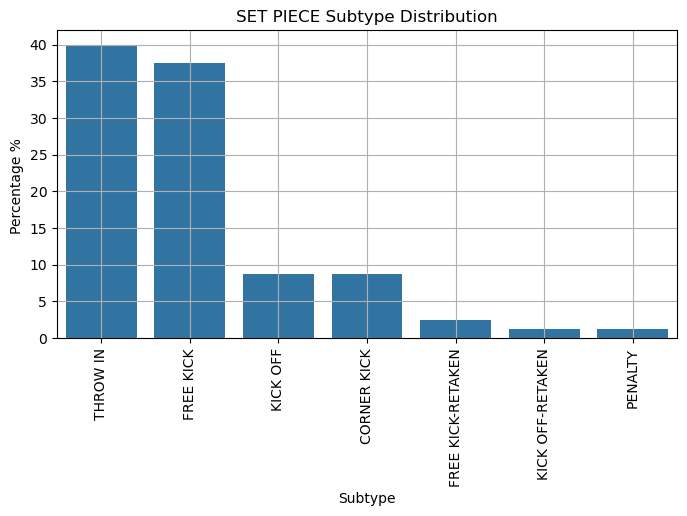

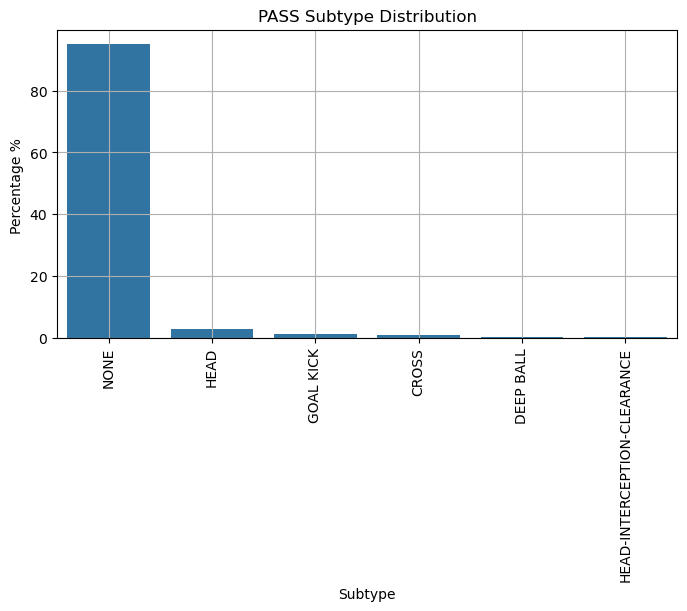

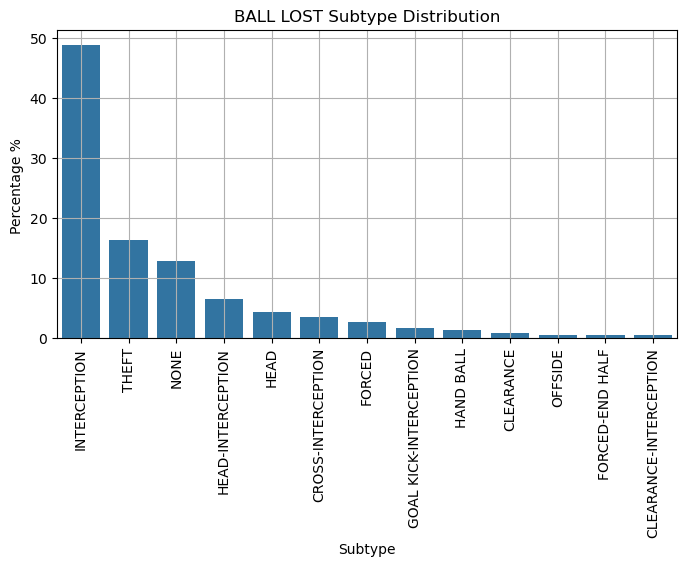

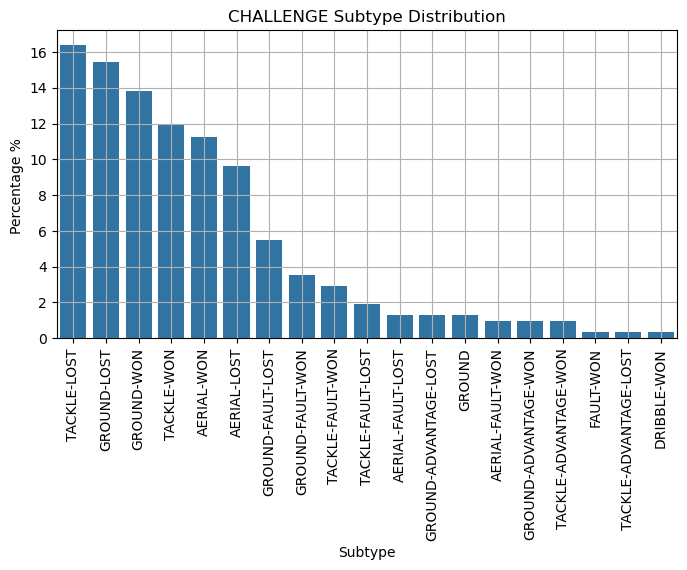

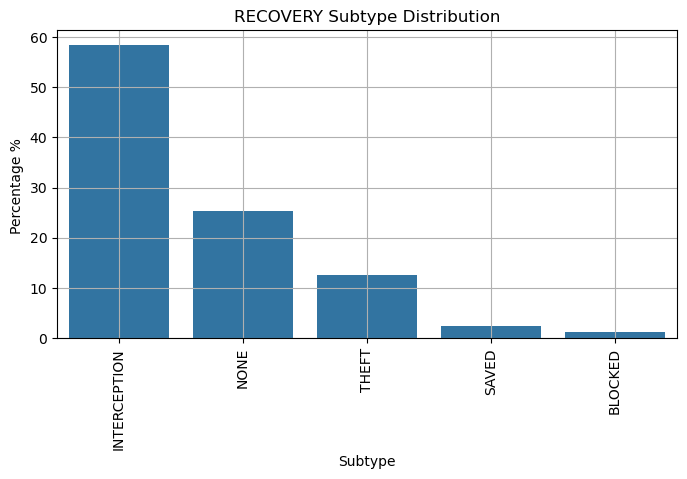

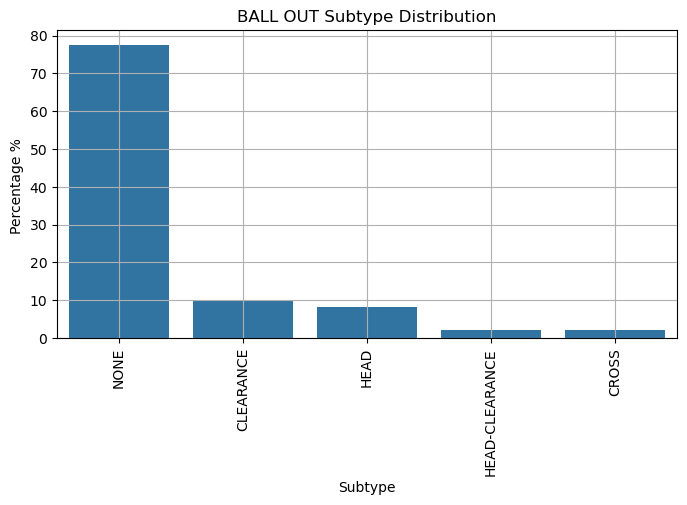

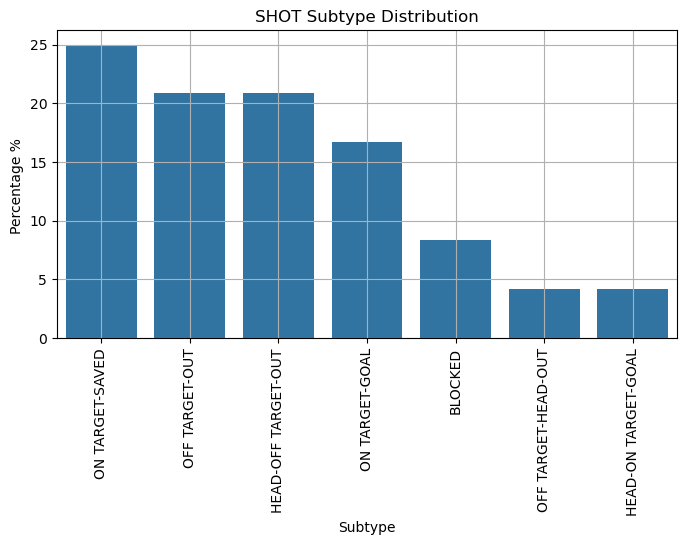

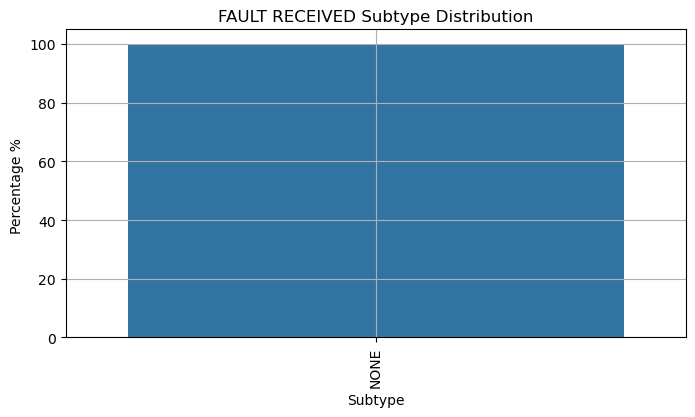

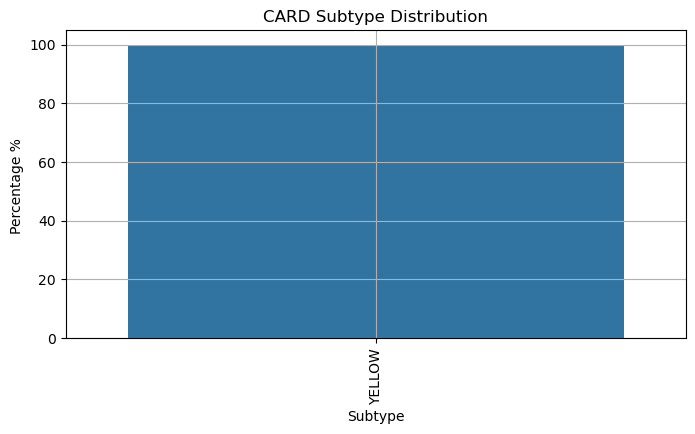

In [52]:
plot_subtype_distribution(events)